# Problem Statement
Segment an online retailer's ~1M transactions into distinct customer groups based on purchasing behavior (Recency, Frequency, Monetary), using unsupervised clustering — since no labeled "customer type" exists — so the business can identify high-value customers, at-risk/churning customers, and outliers, instead of treating every customer the same.

#### Attribute Information:

* **InvoiceNo** - Invoice number. Nominal. A 6-digit integral number uniquely assigned to each transaction.\
If this code starts with the letter 'c', it indicates a cancellation.

* **StockCode** - Product (item) code. Nominal. A 5-digit integral number uniquely assigned to each distinct product. 
* Description - Product (item) name. Nominal.

* **Quantity** - The quantities of each product (item) per transaction. Numeric.

* **InvoiceDate** - Invice date and time. Numeric. The day and time when a transaction was generated.

* **UnitPrice** - Unit price. Numeric. Product price per unit in sterling (Â£).

* **CustomerID** - Customer number. Nominal. A 5-digit integral number uniquely assigned to each customer.

* **Country** - Country name. Nominal. The name of the country where a customer resides.



---

# Cleaning and EDA

#### Basic Libraries for Data Handling and Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load the data

In [2]:
retail_df = pd.read_csv("../Data/online_retail_II.csv")

Let's take a look at some samples from the entire dataset

In [3]:
retail_df.sample(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
639490,546007,21905,MORE BUTTER METAL SIGN,1,2011-03-08 15:34:00,1.63,NaN,United Kingdom
274113,516027,84755,COLOUR GLASS T-LIGHT HOLDER HANGING,16,2010-07-16 10:36:00,0.65,16175.0,United Kingdom
398523,527474,22732,3D VINTAGE CHRISTMAS STICKERS,1,2010-10-18 11:25:00,1.25,17220.0,United Kingdom
332460,521896,20725,LUNCH BAG RED SPOTTY,10,2010-09-09 12:19:00,1.65,12682.0,France
9303,490128,90200B,BLACK SWEETHEART BRACELET,2,2009-12-03 18:23:00,4.25,15884.0,United Kingdom


Let's check the `shape` of `reatil_df`

In [4]:
retail_df.shape

(1067371, 8)

Let's take a look at the `info()` of the dataset

In [5]:
retail_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 65.1 MB


Here `InvoiceDate` and `CustomerID` are in the wrong `Dtype`, let's convert `InvoiceDate` in its correct `Dtype` and `CustomerID` after `NULL` hnadling.

In [6]:
retail_df['InvoiceDate'] = pd.to_datetime(retail_df['InvoiceDate'])

Let's check if we have duplicates

In [7]:
retail_df.duplicated().sum()

np.int64(34335)

Let's look at the actual duplicate rows, not just the count

In [8]:
retail_df[retail_df.duplicated(keep=False)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
367,489517,22319,HAIRCLIPS FORTIES FABRIC ASSORTED,12,2009-12-01 11:34:00,0.65,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067136,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
1067150,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
1067153,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
1067160,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


**Note:** *`keep=False` marks all occurrences of a duplicated row as `True`, including the first one. so filtering on this shows us the full pairs/groups of duplicates together, which is what we actually want to visually inspect.*

It seems we have a lot of duplicates in `Invoice` column. Let's inspect it:

In [9]:
retail_df['Invoice'].value_counts()

Invoice
537434     1350
538071     1304
537638     1202
537237     1194
536876     1186
           ... 
581487        1
581491        1
C581499       1
581566        1
C581568       1
Name: count, Length: 53628, dtype: int64

Here, the multiple same values of `Invoice` are not duplicates because one Invoice number represents one checkout/order, and a customer almost never buys just one item per order, they buy several products in the same purchase.

So in the raw data, the table isn't "one row per order," it's one row per item within an order. If a customer buys 5 different products in a single checkout, that single Invoice number gets stamped on 5 separate rows — one row per product, each with its own StockCode, Description, Quantity, UnitPrice.

Let's check if we have `NULL` values

In [10]:
retail_df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Let's drop the rows with `NULL` value in `CustomerID` column. we are not going to do anything about `NULL` in `Description` column\
because we won't be using it in RFM or clustering.

In [11]:
retail_df = retail_df.dropna(subset=['Customer ID'])

Let's cast the Dtype of `Customer ID` from *float* to *int*, we couldn't do it earlier because we had `NULL` values

In [12]:
retail_df['Customer ID'] = retail_df['Customer ID'].astype(int)

Let's look at the stats of the dataset

In [13]:
retail_df.describe()

,Quantity,InvoiceDate,Price,Customer ID
count,824364.000000,824364,824364.000000,824364.000000
mean,12.414574,2011-01-01 22:29:28.042055,3.676800,15324.638504
min,-80995.000000,2009-12-01 07:45:00,0.000000,12346.000000
25%,2.000000,2010-07-06 11:58:00,1.250000,13975.000000
50%,5.000000,2010-12-03 14:26:00,1.950000,15255.000000
75%,12.000000,2011-07-27 15:14:00,3.750000,16797.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,188.976099,NaN,70.241388,1697.464450


It seems we have `Price = 0` which is not feasible, let's inspect

In [14]:
retail_df[retail_df['Price'] == 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108,United Kingdom
18739,490961,22142,CHRISTMAS CRAFT WHITE FAIRY,12,2009-12-08 15:25:00,0.0,14108,United Kingdom
...,...,...,...,...,...,...,...,...
1004540,577129,22464,HANGING METAL HEART LANTERN,4,2011-11-17 19:52:00,0.0,15602,United Kingdom
1005014,577168,M,Manual,1,2011-11-18 10:42:00,0.0,12603,Germany
1006110,577314,23407,SET OF 2 TRAYS HOME SWEET HOME,2,2011-11-18 13:23:00,0.0,12444,Norway
1011446,577696,M,Manual,1,2011-11-21 11:57:00,0.0,16406,United Kingdom


Let's drop these 71 rows (0.01% of data) with Price = 0, as they represent non-sale entries (samples/adjustments) and contribute no monetary value to RFM features.

In [15]:
retail_df = retail_df[retail_df['Price'] != 0]

We seem to have some `Quantity` negative values, which seems impossible. Let's inspect:

In [16]:
retail_df[retail_df['Quantity'] <= 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315,United Kingdom


Okay this confirms that these are *Cancelled* purchases which is feasible; but a cancelled order was never actually fulfilled.\
It's not "purchase behavior" at all — it's the absence of a completed purchase. So let's drop them:

In [17]:
retail_df = retail_df[retail_df['Quantity'] > 0]

By looking at our dataset's stats (`retail_df.describe()`), 75% of the transaction happend with 12 units of products whereas max is 80995,\
which is a very big jump let's inspect this.

In [18]:
retail_df['Quantity'].quantile([0.75, 0.8, 0.85, 0.9, 0.95, 0.97, 0.99])

0.75     12.0
0.80     12.0
0.85     16.0
0.90     24.0
0.95     36.0
0.97     50.0
0.99    128.0
Name: Quantity, dtype: float64

In [19]:
retail_df[retail_df['Quantity'] > 1000]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
7302,490018,21981,PACK OF 12 WOODLAND TISSUES,4320,2009-12-03 12:31:00,0.25,17940,United Kingdom
7303,490018,21967,PACK OF 12 SKULL TISSUES,5184,2009-12-03 12:31:00,0.25,17940,United Kingdom
7304,490018,21984,PACK OF 12 PINK PAISLEY TISSUES,4008,2009-12-03 12:31:00,0.25,17940,United Kingdom
7305,490018,21980,PACK OF 12 RED SPOTTY TISSUES,4008,2009-12-03 12:31:00,0.25,17940,United Kingdom
22100,491133,16014,SMALL CHINESE STYLE SCISSOR,1500,2009-12-09 16:17:00,0.32,13848,United Kingdom
...,...,...,...,...,...,...,...,...
1059273,581115,22413,METAL SIGN TAKE IT OR LEAVE IT,1404,2011-12-07 12:20:00,2.75,15195,United Kingdom
1060413,581175,23084,RABBIT NIGHT LIGHT,1440,2011-12-07 15:16:00,1.79,14646,Netherlands
1065531,581458,22197,POPCORN HOLDER,1500,2011-12-08 18:45:00,0.72,17949,United Kingdom
1065532,581459,22197,POPCORN HOLDER,1200,2011-12-08 18:46:00,0.72,17949,United Kingdom


That confirms, most of these items are TISSUES which make sense, people buy them extra to stock.

---

# RFM feature engineering

*RFM = Recency, Frequency, Monetary.* Three numbers that summarize each customer's purchasing behavior, computed from their entire transaction history.

* **Recency** — how many days ago was their last purchase? Lower = more recently active.
* **Frequency** — how many separate orders have they placed? Higher = more loyal/repeat customer.
* **Monetary** — how much money have they spent in total? Higher = more valuable customer.

***Why we need this step:***\
the cleaned dataset has ~800K+ rows, but each row is one item within one order — not one row per customer. Clustering algorithms need one row per entity being grouped, so before we can segment customers, we have to collapse each customer's entire transaction history into a single row of 3 summary numbers. That's what this step does — it goes from "every item anyone ever bought" to "one behavioral profile per customer."

These 3 numbers are what actually get fed into PCA, K-Means, Hierarchical clustering, and DBSCAN later — not the raw transaction data.

One thing to nail down before going forward: what "today" means for Recency. You need a fixed reference date to measure "days since last purchase" against. Two options:

* Real today's date (`pd.Timestamp.now()`) — wrong for this dataset, since the data is from 2009-2011. Every customer would show Recency of ~15+ years, which is meaningless.
* One day after the last transaction in the dataset — the standard approach for historical data. Treats the day after the most recent recorded purchase as "now," so Recency values are meaningful relative to the dataset's own timeline.

In [20]:
latest_date = retail_df['InvoiceDate'].max() + pd.Timedelta(days=1)
latest_date

Timestamp('2011-12-10 12:50:00')

**NOTE:** *`+ pd.Timedelta(days=1)` — pushes it one day forward, so even a customer who bought on the very last day has a Recency of 1, not 0 (avoids a slightly awkward zero-day edge case)*

#### Now build the RFM table itself.

First, we need a `TotalPrice` column — it doesn't exist yet, and Monetary depends on it:

In [21]:
retail_df['TotalPrice'] = retail_df['Quantity'] * retail_df['Price']

#### Now the RFM aggregation:

In [22]:
rfm = retail_df.groupby('Customer ID').agg(
    Recency = ('InvoiceDate', lambda x: (latest_date - x.max()).days),
    Frequency = ('Invoice', 'nunique'),
    Monetary = ('TotalPrice', 'sum')
).reset_index()

**NOTE:** *`groupby` makes `CustomerID` the index by default; `.reset_index()` turns it back into a normal column*

In [23]:
rfm

,Customer ID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40
...,...,...,...,...
5873,18283,4,22,2736.65
5874,18284,432,1,461.68
5875,18285,661,1,427.00
5876,18286,477,2,1296.43


Now let's do the sanity-check the RFM table

In [24]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,15315.313542,201.331916,6.289384,3018.616737
std,1715.572666,209.338707,13.009406,14737.731040
min,12346.000000,1.000000,1.000000,2.950000
25%,13833.250000,26.000000,1.000000,348.762500
50%,15314.500000,96.000000,3.000000,898.915000
75%,16797.750000,380.000000,7.000000,2307.090000
max,18287.000000,739.000000,398.000000,608821.650000


For `Monetary`, mean is **3,018** but the median (50%) is only **898** — meaning a small number of very large spenders are dragging the average way up. Confirmed by the `max: 608,821` — that's roughly 200x the 75th percentile (2,307). That's not a "big spender," that's almost certainly a wholesale/business buyer, not a typical retail customer, sitting in the same table as everyone else.

Let's investigate this specific customer:

In [25]:
rfm.sort_values('Monetary', ascending=False).head(10)

,Customer ID,Recency,Frequency,Monetary
5692,18102,1,145,608821.65
2277,14646,2,151,528602.52
1789,14156,10,156,313946.37
2538,14911,1,398,295972.63
5050,17450,8,51,246973.09
1331,13694,4,143,196482.81
5109,17511,3,60,175603.55
4061,16446,1,2,168472.50
4295,16684,4,55,147142.77
68,12415,24,28,144458.37


Look at the pattern: 608K → 528K → 313K → 295K → 246K → 196K → 175K → 168K → 147K → 144K. That's a gradual decline,\
not a single freak value miles above everyone else with a cliff after it.

This isn't a data error — this looks like a genuine population of wholesale/B2B buyers\
sitting inside a dataset that's mostly individual retail customers. 

High Frequency (51-398 orders) mostly supports this — these are accounts ordering constantly, consistent with a business restocking inventory,\
not someone buying home decor for themselves.

`CustomerID 16446` — *Recency=1*, *Frequency=2*, *Monetary=168,472*. That's wildly different behaviorally from the rest of this list.\
Let's investigate:

In [26]:
retail_df[retail_df['Customer ID'] == 16446]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
719815,553573,22980,PANTRY SCRUBBING BRUSH,1,2011-05-18 09:52:00,1.65,16446,United Kingdom,1.65
719816,553573,22982,PANTRY PASTRY BRUSH,1,2011-05-18 09:52:00,1.25,16446,United Kingdom,1.25
1065882,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom,168469.60


CustomerID 16446 shows an extreme single-order Quantity (80,995 units) that may represent a genuine bulk order or a data entry error; this cannot be conclusively determined from the data alone. This transaction — along with several other high-volume wholesale-pattern customers — was retained to allow DBSCAN to identify structural outliers naturally rather than removing them via arbitrary judgment calls."

Now, the actual next step — **`log-transform`** `Monetary` before scaling because our `Monetary` column ranges from £2.95 to £608,821 — a ~200,000x spread. Mean (3,018) is 3x the median (898), which we correctly identified as heavy right-skew: a small number of huge spenders, a large number of ordinary ones.

same for `Frequency` as well because its median is 3, but max is 398 — that's over 130x the median. Mean is 6.29, nearly double the median of 3.\
Same signature as `Monetary`

In [27]:
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])
rfm['Frequency_log'] = np.log1p(rfm['Frequency'])

Let's Check the its effect:

In [28]:
rfm[['Monetary', 'Monetary_log', 'Frequency', 'Frequency_log']].describe()

,Monetary,Monetary_log,Frequency,Frequency_log
count,5878.000000,5878.000000,5878.000000,5878.000000
mean,3018.616737,6.836550,6.289384,1.549588
std,14737.731040,1.387864,13.009406,0.809447
min,2.950000,1.373716,1.000000,0.693147
25%,348.762500,5.857254,1.000000,0.693147
50%,898.915000,6.802300,3.000000,1.386294
75%,2307.090000,7.744175,7.000000,2.079442
max,608821.650000,13.319282,398.000000,5.988961


As you can see the `mean` and `median` values of `Monetary_log` and `Frequency_log` is way closer than before,\
meaning the skewness of our data has been reduced.

Let's check the skewness of `Recency`

<Axes: >

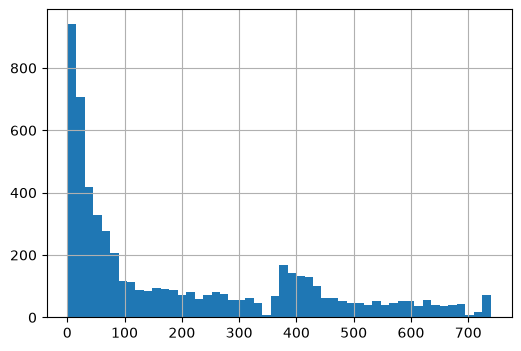

In [29]:
rfm['Recency'].hist(bins=50, figsize=(6, 4))

`Log-transform` applied to *Monetary* and *Frequency* to address extreme right-skew from outlier customers. *Recency* was left untransformed — its distribution is multi-modal rather than skewed by outliers, likely reflecting distinct customer groups (recently active vs. churned since the dataset's first year), and log-transforming would obscure this structure rather than clarify it.

---

# Preprocessing

Let's build our final feature matrix for scaling:

In [37]:
features = rfm[['Recency', 'Frequency_log', 'Monetary_log']]

#### Let's scale

In [31]:
from sklearn.preprocessing import StandardScaler

In [38]:
scaler = StandardScaler()

In [39]:
feature_scaled = scaler.fit_transform(features)

Let's convert it back to a labeled DataFrame (we lost column names and CustomerID in the NumPy array form):

In [45]:
feature_scaled_df = pd.DataFrame(feature_scaled, columns=features.columns, index=rfm['Customer ID'])

In [46]:
feature_scaled_df.describe()

,Recency,Frequency_log,Monetary_log
count,5.878000e+03,5.878000e+03,5.878000e+03
mean,-4.230860e-17,2.381370e-16,-4.351742e-16
std,1.000085e+00,1.000085e+00,1.000085e+00
min,-9.570564e-01,-1.058146e+00,-3.936481e+00
25%,-8.376226e-01,-1.058146e+00,-7.056734e-01
50%,-5.032078e-01,-2.017514e-01,-2.467978e-02
75%,8.535607e-01,6.546432e-01,6.540289e-01
max,2.568631e+00,5.484918e+00,4.671413e+00


It shows mean ≈ 0 and std ≈ 1 for all three columns, that's our actual confirmation the scaling is correct.

Let's save both tables now, so *Notebook 1* ends cleanly and *Notebook 2* can start fresh:

In [49]:
rfm.to_csv('rfm.csv', index=False)
feature_scaled_df.to_csv('feature_scaled.csv')